## Linear Regression

               id   Date  number of bedrooms  number of bathrooms  \
0      6762810635  42491                   4                 2.50   
1      6762810998  42491                   5                 2.75   
2      6762812605  42491                   4                 2.50   
3      6762812919  42491                   3                 2.00   
4      6762813105  42491                   3                 2.50   
...           ...    ...                 ...                  ...   
14614  6762830250  42734                   2                 1.50   
14615  6762830339  42734                   3                 2.00   
14616  6762830618  42734                   2                 1.00   
14617  6762830709  42734                   4                 1.00   
14618  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             2920      4000               1.5                   0   
1             2910      9480   

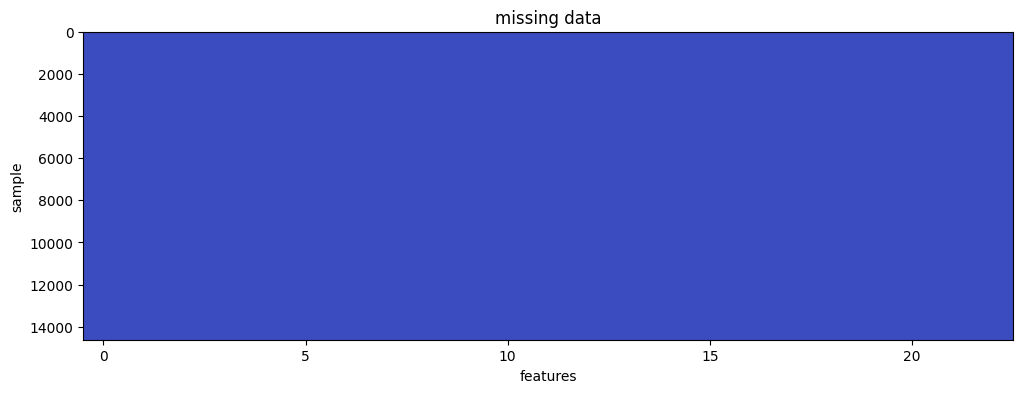

                                             id      Date  number of bedrooms  \
id                                     1.000000  0.045778           -0.328899   
Date                                   0.045778  1.000000           -0.015467   
number of bedrooms                    -0.328899 -0.015467            1.000000   
number of bathrooms                   -0.516909 -0.026433            0.509783   
living area                           -0.648058 -0.021770            0.570441   
lot area                              -0.100298  0.004374            0.034438   
number of floors                      -0.312237 -0.010230            0.177208   
waterfront present                    -0.112959  0.011997           -0.006247   
number of views                       -0.292699 -0.004219            0.078157   
condition of the house                -0.044797 -0.027138            0.026326   
grade of the house                    -0.673374 -0.032878            0.352795   
Area of the house(excluding 

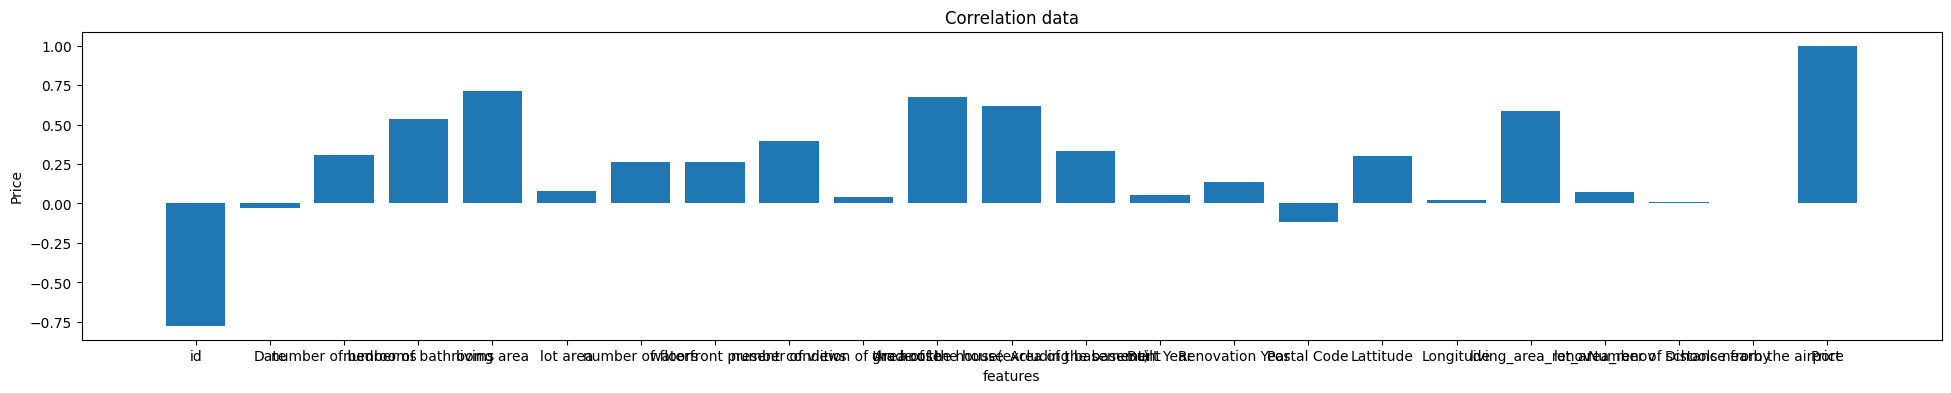

selected features are  Index(['number of bedrooms', 'number of bathrooms', 'living area',
       'number of floors', 'waterfront present', 'number of views',
       'grade of the house', 'Area of the house(excluding basement)',
       'Area of the basement', 'Renovation Year', 'Lattitude',
       'living_area_renov', 'Price'],
      dtype='object')
Train R2: 0.662261672928253
Test R2: 0.6763880444781989
Train MSE: 23312652122.067726


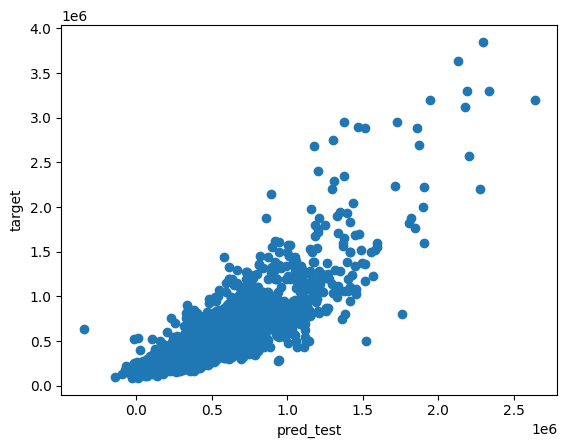

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#LOADING DATASET

data = pd.read_csv("House Price India.csv")
print(data)

# E D A
d_sh = data.shape
print(d_sh)

           #missing data kitne haii
data.isnull().sum()

plt.figure(figsize =(12,4))
plt.imshow(data.isnull(),aspect = 'auto',cmap = 'coolwarm')
plt.xlabel("features")
plt.ylabel("sample")
plt.title("missing data")
plt.show()

#correction
corr = data.corr(numeric_only = True)
print(corr)

price_data = corr["Price"]

plt.figure(figsize = (24,4))
plt.bar(price_data.index,price_data.values)
plt.xlabel("features")
plt.ylabel("Price")
plt.title("Correlation data")
plt.show()

#data cleaning
threshold = 0.1

selected_features = price_data[price_data >=threshold].index
print("selected features are ", selected_features)

#distributing data
data_filtered = data[selected_features]
X = data_filtered.drop("Price",axis= 1).to_numpy()

Y = data["Price"].to_numpy()

#randomising

np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
Y = Y[indices]

#splitting
split = int(0.8*(len(X)))
X_train = X[:split]
X_test = X[split:]
Y_train = Y[:split]
Y_test = Y[split:]

#scaling
mean = X_train.mean(axis = 0)
std = X_train.std(axis = 0)
X_train = (X_train - mean)/std
X_test = (X_test - mean) / std

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test  = np.c_[np.ones(X_test.shape[0]), X_test]


#model

def mse(y_true,y_pred,gamma,w):
    m = len(y_true)
    
    mse = (1/(2*m)) * np.sum((y_true - y_pred)**2)
    reg = (gamma/(2 * m)) * np.sum((w[1:])**2)
    return mse + reg

def Gradient_descent(alpha,x,y,iterations):

    w = np.zeros(x.shape[1])

    tol = 1e-6
    prev_cost = float("inf")

    for _ in range(iterations):
        y_pred = x @ w

        cost = mse(y,y_pred,gamma,w)
        
        if abs(prev_cost - cost) <= tol:
            break
        prev_cost = cost
        dj_dw = Gradient_func(x,gamma,w,y_pred,y)
        w = w - (alpha * dj_dw)
    return w

def Gradient_func(x,gamma,w,y_pred,y):
    m = len(x)
    dj_dw = ((1/m)*(x.T @ (y_pred - y))) 
    dj_dw[1:] += (gamma/m)*(w[1:])

    return dj_dw

def r2_score(y_true,y_pred):
    ss_res = np.sum((y_true-y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2 )
    return 1- (ss_res/ss_tot)

alpha = 0.001
epochs = 4000
gamma = 0.001

w = Gradient_descent(alpha,X_train,Y_train,epochs)

y_pred_train = X_train @ w
y_pred_test = X_test @ w
print("Train R2:", r2_score(Y_train, y_pred_train))
print("Test R2:", r2_score(Y_test, y_pred_test))
print("Train MSE:", mse(Y_train,y_pred_train,gamma,w))

plt.scatter(y_pred_test,Y_test)
plt.xlabel("pred_test")
plt.ylabel("target")
plt.title("")
plt.show()


## Polynomial Regression

               id   Date  number of bedrooms  number of bathrooms  \
0      6762810635  42491                   4                 2.50   
1      6762810998  42491                   5                 2.75   
2      6762812605  42491                   4                 2.50   
3      6762812919  42491                   3                 2.00   
4      6762813105  42491                   3                 2.50   
...           ...    ...                 ...                  ...   
14614  6762830250  42734                   2                 1.50   
14615  6762830339  42734                   3                 2.00   
14616  6762830618  42734                   2                 1.00   
14617  6762830709  42734                   4                 1.00   
14618  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             2920      4000               1.5                   0   
1             2910      9480   

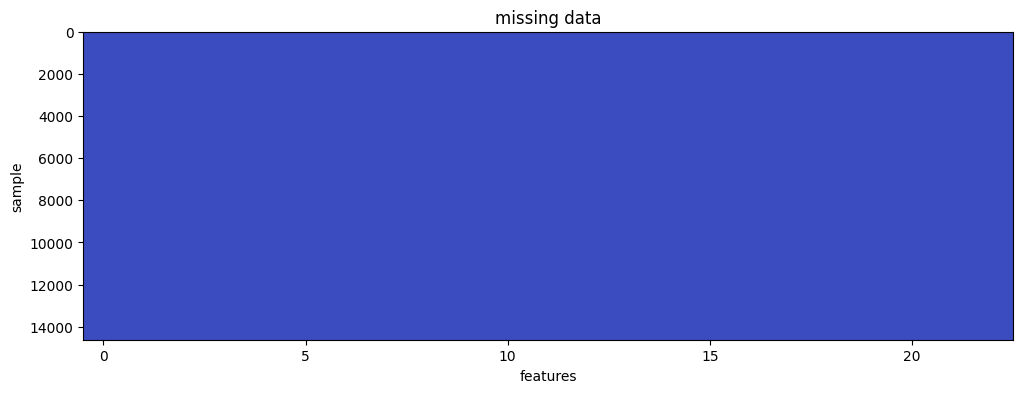

                                             id      Date  number of bedrooms  \
id                                     1.000000  0.045778           -0.328899   
Date                                   0.045778  1.000000           -0.015467   
number of bedrooms                    -0.328899 -0.015467            1.000000   
number of bathrooms                   -0.516909 -0.026433            0.509783   
living area                           -0.648058 -0.021770            0.570441   
lot area                              -0.100298  0.004374            0.034438   
number of floors                      -0.312237 -0.010230            0.177208   
waterfront present                    -0.112959  0.011997           -0.006247   
number of views                       -0.292699 -0.004219            0.078157   
condition of the house                -0.044797 -0.027138            0.026326   
grade of the house                    -0.673374 -0.032878            0.352795   
Area of the house(excluding 

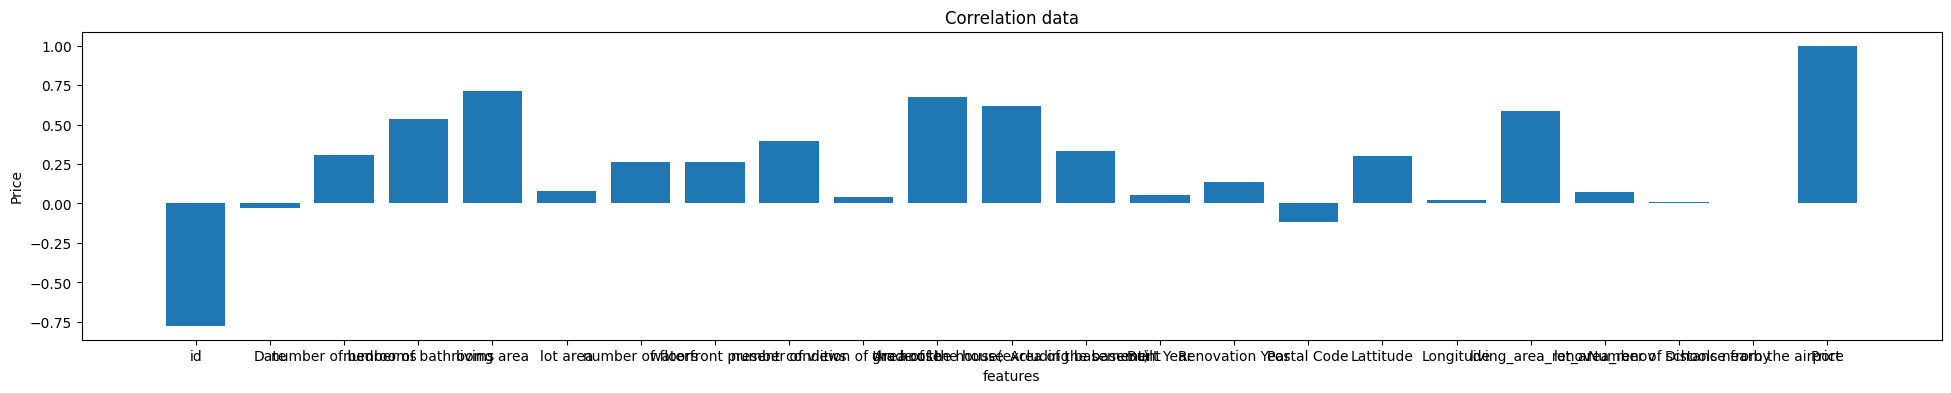

selected features are  Index(['number of bedrooms', 'number of bathrooms', 'living area',
       'number of floors', 'waterfront present', 'number of views',
       'grade of the house', 'Area of the house(excluding basement)',
       'Area of the basement', 'Renovation Year', 'Lattitude',
       'living_area_renov', 'Price'],
      dtype='object')
Train R2: 0.7766014386588321
Test R2: 0.6827894290632099
Train MSE: 15420259383.689878
Train MSE: 19352869414.53043


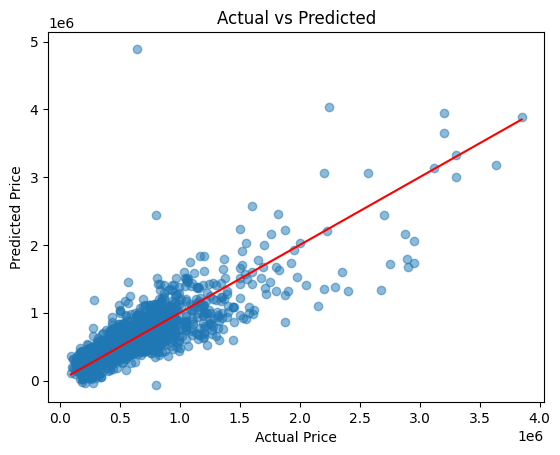

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#LOADING DATASET

data = pd.read_csv("House Price India.csv")
print(data)

# E D A
d_sh = data.shape
print(d_sh)

           #missing data kitne haii
data.isnull().sum()

plt.figure(figsize =(12,4))
plt.imshow(data.isnull(),aspect = 'auto',cmap = 'coolwarm')
plt.xlabel("features")
plt.ylabel("sample")
plt.title("missing data")
plt.show()

#correction
corr = data.corr(numeric_only = True)
print(corr)

price_data = corr["Price"]

plt.figure(figsize = (24,4))
plt.bar(price_data.index,price_data.values)
plt.xlabel("features")
plt.ylabel("Price")
plt.title("Correlation data")
plt.show()

#data cleaning
threshold = 0.1

selected_features = price_data[price_data >=threshold].index
print("selected features are ", selected_features)

#distributing data
data_filtered = data[selected_features]
X = data_filtered.drop("Price",axis= 1).to_numpy()

Y = data["Price"].to_numpy()

#randomising

np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
Y = Y[indices]

#splitting
split = int(0.8*(len(X)))
X_train = X[:split]
X_test = X[split:]
Y_train = Y[:split]
Y_test = Y[split:]

#scaling
mean = X_train.mean(axis = 0)
std = X_train.std(axis = 0)
X_train = (X_train - mean)/std
X_test = (X_test - mean) / std

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test  = np.c_[np.ones(X_test.shape[0]), X_test]

#model

def polynomial(X,degrees):
    X_poly = X.copy()
    for i in range(2,degrees+1):
        X_poly = np.c_[X_poly,X[:,1:]**i]

    return X_poly

def mse(y_true,y_pred,gamma,w):
    m = len(y_true)
    
    mse = (1/(2*m)) * np.sum((y_true - y_pred)**2)
    reg = (gamma/(2 * m)) * np.sum((w[1:])**2)
    return mse + reg

def mse_eval(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def Gradient_descent(alpha,x,y,iterations):

    w = np.zeros(x.shape[1])

    tol = 1e-6
    prev_cost = float("inf")

    for _ in range(iterations):
        y_pred = x @ w

        cost = mse(y,y_pred,gamma,w)
        
        if abs(prev_cost - cost) <= tol:
            break
        prev_cost = cost
        dj_dw = Gradient_func(x,gamma,w,y_pred,y)
        w = w - (alpha * dj_dw)
    return w

def Gradient_func(x,gamma,w,y_pred,y):
    m = len(x)
    dj_dw = ((1/m)*(x.T @ (y_pred - y))) 
    dj_dw[1:] += (gamma/m)*(w[1:])

    return dj_dw

def r2_score(y_true,y_pred):
    ss_res = np.sum((y_true-y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2 )
    return 1- (ss_res/ss_tot)

alpha = 0.01
epochs = 4000
gamma = 0.01


degree = 2
X_train_poly = polynomial(X_train,degree)
X_test_poly = polynomial(X_test,degree)

w = Gradient_descent(alpha,X_train_poly,Y_train,epochs)

y_pred_train = X_train_poly @ w
y_pred_test = X_test_poly @ w
print("Train R2:", r2_score(Y_train, y_pred_train))
print("Test R2:", r2_score(Y_test, y_pred_test))
print("Train MSE:", mse_eval(Y_train,y_pred_train))
print("Train MSE:", mse_eval(Y_test,y_pred_test))

plt.scatter(Y_test, y_pred_test, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],'r')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


## BETTER POLY REG

               id   Date  number of bedrooms  number of bathrooms  \
0      6762810635  42491                   4                 2.50   
1      6762810998  42491                   5                 2.75   
2      6762812605  42491                   4                 2.50   
3      6762812919  42491                   3                 2.00   
4      6762813105  42491                   3                 2.50   
...           ...    ...                 ...                  ...   
14614  6762830250  42734                   2                 1.50   
14615  6762830339  42734                   3                 2.00   
14616  6762830618  42734                   2                 1.00   
14617  6762830709  42734                   4                 1.00   
14618  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             2920      4000               1.5                   0   
1             2910      9480   

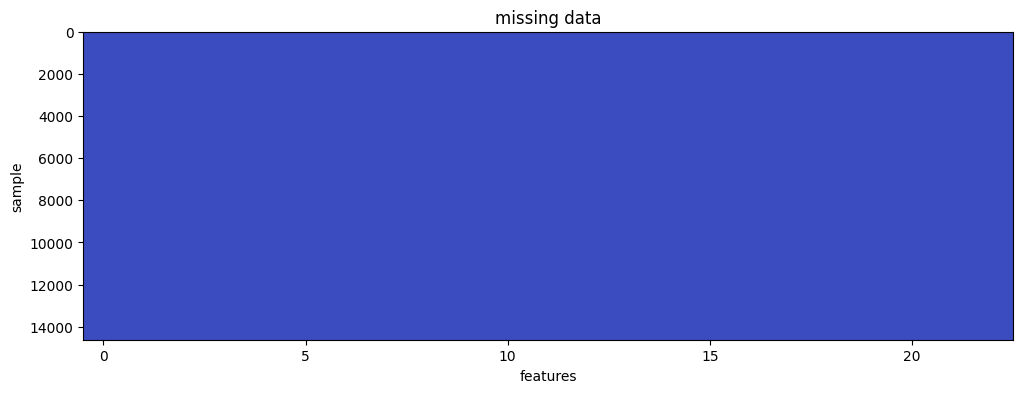

                                             id      Date  number of bedrooms  \
id                                     1.000000  0.045778           -0.328899   
Date                                   0.045778  1.000000           -0.015467   
number of bedrooms                    -0.328899 -0.015467            1.000000   
number of bathrooms                   -0.516909 -0.026433            0.509783   
living area                           -0.648058 -0.021770            0.570441   
lot area                              -0.100298  0.004374            0.034438   
number of floors                      -0.312237 -0.010230            0.177208   
waterfront present                    -0.112959  0.011997           -0.006247   
number of views                       -0.292699 -0.004219            0.078157   
condition of the house                -0.044797 -0.027138            0.026326   
grade of the house                    -0.673374 -0.032878            0.352795   
Area of the house(excluding 

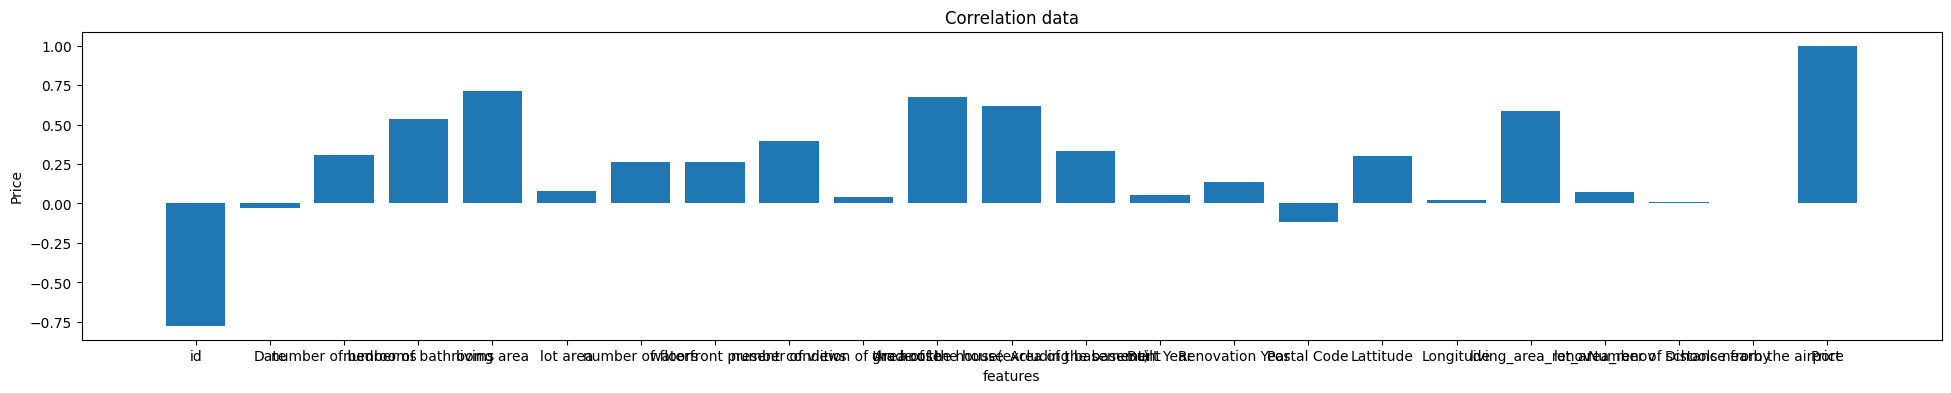

selected features are  Index(['number of bedrooms', 'number of bathrooms', 'living area',
       'number of floors', 'waterfront present', 'number of views',
       'grade of the house', 'Area of the house(excluding basement)',
       'Area of the basement', 'Renovation Year', 'Lattitude',
       'living_area_renov', 'Price'],
      dtype='object')
Train R2: 0.7616929472565975
Test R2: 0.7542496478722285
Train MSE:  21573330881.023487
Test  MSE:  36514979675.09045
Train RMSE:  146878.62635871663
Test  RMSE:  191088.93132541835
MAPE Test:  19.152179866203607


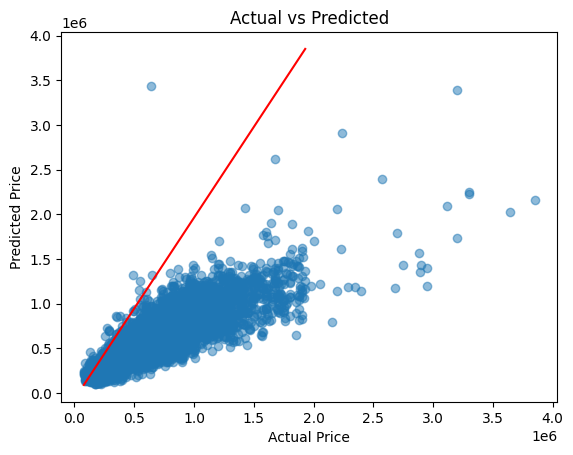

min price 78000
max price 7700000


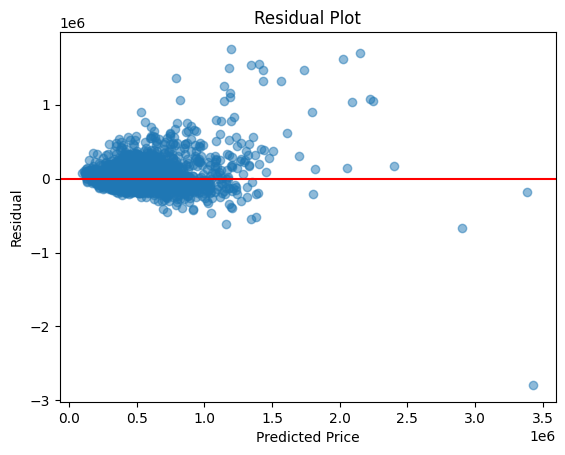

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#LOADING DATASET

data = pd.read_csv("House Price India.csv")
print(data)

# E D A
d_sh = data.shape
print(d_sh)

           #missing data kitne haii
data.isnull().sum()

plt.figure(figsize =(12,4))
plt.imshow(data.isnull(),aspect = 'auto',cmap = 'coolwarm')
plt.xlabel("features")
plt.ylabel("sample")
plt.title("missing data")
plt.show()

#correction
corr = data.corr(numeric_only = True)
print(corr)

price_data = corr["Price"]

plt.figure(figsize = (24,4))
plt.bar(price_data.index,price_data.values)
plt.xlabel("features")
plt.ylabel("Price")
plt.title("Correlation data")
plt.show()

#data cleaning
threshold = 0.1

selected_features = price_data[price_data >=threshold].index
print("selected features are ", selected_features)

#distributing data
data_filtered = data[selected_features]
X = data_filtered.drop("Price",axis= 1).to_numpy()

Y = data["Price"].to_numpy()
Y_log = np.log(Y)
#randomising

np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
Y_log = Y_log[indices]

#splitting
split = int(0.8*(len(X)))
X_train = X[:split]
X_test = X[split:]
Y_train = Y_log[:split]
Y_test = Y_log[split:]


#removing extreme outliers
price = np.exp(Y_train)
mask = price < np.percentile(price, 99)

X_train = X_train[mask]
Y_train = Y_train[mask]

#scaling
mean = X_train.mean(axis = 0)
std = X_train.std(axis = 0)
std[std ==0] = 1
X_train = (X_train - mean)/std
X_test = (X_test - mean) / std

#model

def polynomial(X):
    X_poly = X.copy()
    n = X.shape[1]

    for i in range(n):
        for j in range(i, n):
            X_poly = np.c_[X_poly, X[:, i] * X[:, j]]

    return X_poly

def mse(y_true,y_pred,gamma,w):
    m = len(y_true)
    
    mse = (1/(2*m)) * np.sum((y_true - y_pred)**2)
    reg = (gamma/(2 * m)) * np.sum((w[1:])**2)
    return mse + reg

def mse_eval(y_true,y_pred):
    return np.mean((y_pred - y_true)**2)

def Gradient_descent(alpha,x,y,iterations):

    w = np.zeros(x.shape[1])

    tol = 1e-6
    prev_cost = float("inf")
    dj_dw = np.ones_like(w)
    for _ in range(iterations):
            
        y_pred = np.clip(x @ w,-20,20)

        cost = mse(y,y_pred,gamma,w)

        if np.isnan(cost) or np.isinf(cost):
            print("Stopping: numerical instability")
            break

        
        if np.linalg.norm(dj_dw) <= tol:
            break
        #prev_cost = cost
        dj_dw = Gradient_func(x,gamma,w,y_pred,y)
        w = w - (alpha * dj_dw)
    return w

def Gradient_func(x,gamma,w,y_pred,y):
    m = len(x)
    dj_dw = ((1/m)*(x.T @ (y_pred - y))) 
    dj_dw[1:] += (gamma/m)*(w[1:])

    return dj_dw

def r2_score(y_true,y_pred):
    ss_res = np.sum((y_true-y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2 )
    return 1- (ss_res/ss_tot)

def mape(y_true,y_pred):
    mape = np.mean(np.abs(y_true-y_pred)/y_true)*100
    return mape

alpha = 0.004
epochs = 1500
gamma = 10

X_train = polynomial(X_train)
X_test  = polynomial(X_test)

mean_poly = X_train.mean(axis=0)
std_poly = X_train.std(axis=0)
std_poly[std_poly == 0] = 1

X_train = (X_train - mean_poly) / std_poly
X_test  = (X_test - mean_poly) / std_poly


X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test  = np.c_[np.ones(X_test.shape[0]), X_test]

w = Gradient_descent(alpha,X_train,Y_train,epochs)

y_pred_train = X_train @ w
y_pred_test = X_test @ w

y_pred_train_antilog = np.exp(y_pred_train)
y_pred_test_antilog = np.exp(y_pred_test)

print("Train R2:", r2_score(Y_train, y_pred_train))
print("Test R2:", r2_score(Y_test, y_pred_test))

meansqerr = mse_eval(np.exp(Y_train),y_pred_train_antilog)
msqerr_test = mse_eval(np.exp(Y_test),y_pred_test_antilog)
print("Train MSE: ", meansqerr)
print("Test  MSE: ",msqerr_test)
print("Train RMSE: ",(meansqerr)**(0.5))
print("Test  RMSE: ",(msqerr_test)**(0.5))
print("MAPE Test: ",mape(np.exp(Y_test),y_pred_test_antilog))

y_tmp = np.exp(Y_test)
plt.scatter(np.hstack((np.exp(Y_train),y_tmp)), np.hstack((y_pred_train_antilog,y_pred_test_antilog)), alpha=0.5)
plt.plot([np.exp(Y_train).min(), np.exp(Y_train).max()],
         [y_tmp.min(), y_tmp.max()],'r')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

print("min price",data['Price'].min())
print("max price",data['Price'].max())

residuals = np.exp(Y_test) - y_pred_test_antilog
plt.scatter(y_pred_test_antilog, residuals, alpha=0.5)
plt.axhline(0, color='r')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


In [ ]:
# 9 l error in test for alpha = 0.0035,epoch = 3500,gamma = 10
# 5.8 l error in test for alpha = 0.0035,epoch = 3000,gamma = 10
# 3.3 l error in test for alpha = 0.0035,epoch = 2500, gamma = 10
# 2.1 l error in test for alpha = 0.0035,epoch = 2000, gamma = 10
# 1.9 l error in test for alpha = 0.0035,epoch = 1500, gamma = 10
